In [58]:
import numpy as np
import matplotlib.pyplot as plt

input_folder = "simulations/X_design/scenario_1_22"

X = np.load(f"{input_folder}/X.npy")
n,d = X.shape
beta = np.load(f"{input_folder}/beta.npy")
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u,  sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()

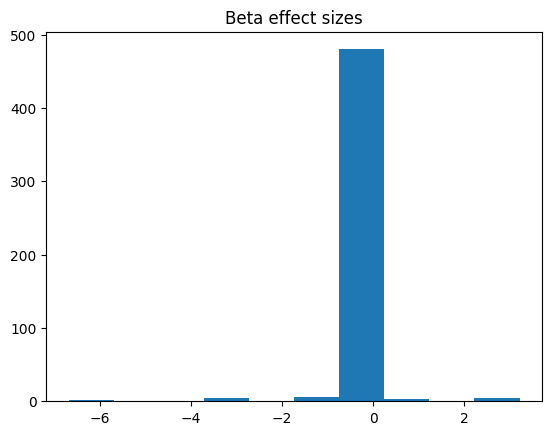

Text(0.5, 1.0, 'OLS estimates using latent y')

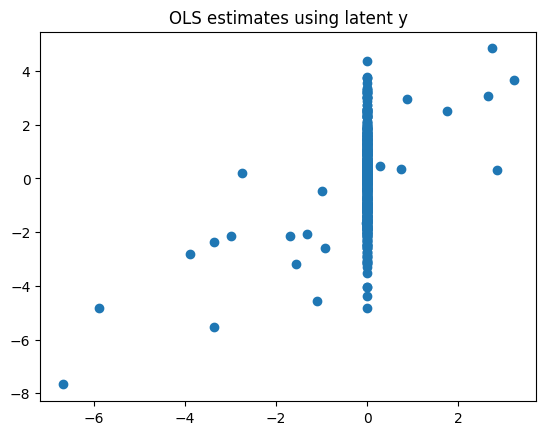

In [78]:
plt.hist(beta)
plt.title("Beta effect sizes")
plt.show()

beta_est = np.linalg.inv(X.T @ X) @ X.T @ ystar
plt.scatter(beta, beta_est)
plt.title("OLS estimates using latent y")

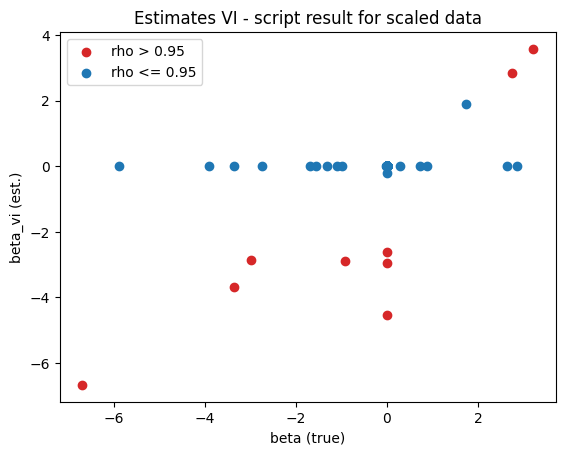

In [145]:
import pandas as pd

df = pd.read_csv("simulations/scenario_1/22/mfvi_22_beta.csv")
df["beta_est"] = df.beta_mean 

mask = df.pip > 0.95
beta_vi = df.beta_est

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - script result for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

MFVI:   0%|          | 0/1100 [00:00<?, ?it/s]

Early stopping


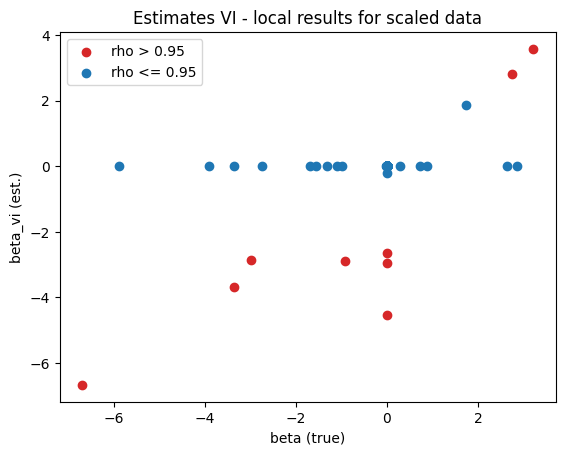

Text(0.5, 1.0, 'ELBO history')

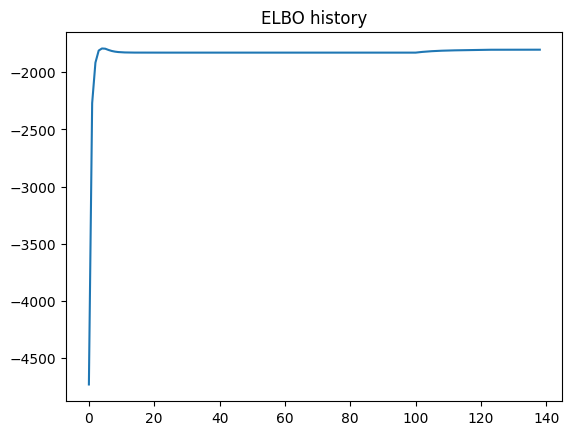

In [144]:
import aux_functions as aux_f
from mfvi_script import summary_orig
    
y_scaled, sigma_y_scaled, l_scaled, u_scaled, mu_y, sd_y = aux_f.scale_y(y, l, u, sigma_y_true)


model_vi = SparseTobitVI(
    X, y_scaled,
    tau2= 1,
    pi0= 0.1, 
    seed= 22,
)

model_vi.fit(
    n_iter = 1000, 
    em_warmup = 100, 
    gamma_batch_size = 1,
    damping = 0.1
)

summary = model_vi.summary()
summary["n_iters"] = len(model_vi.elbo_history)
summary = summary_orig(summary, mu_y, sd_y, 0)

beta_vi = summary["m"]

mask = summary["rho"] > 0.95

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - local results for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

plt.plot(model_vi.elbo_history)
plt.title("ELBO history")

MFVI:   0%|          | 0/1100 [00:00<?, ?it/s]

Early stopping


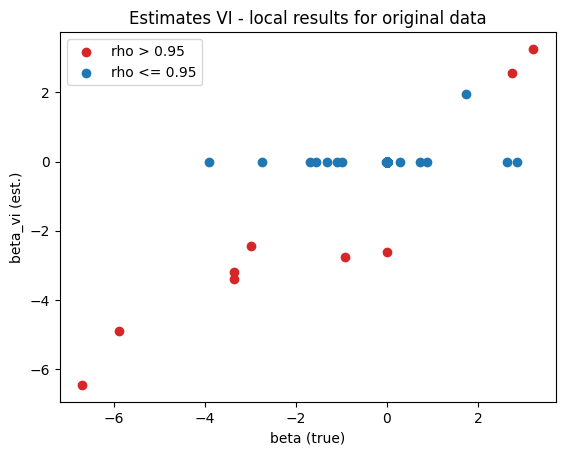

In [143]:
model_vi = SparseTobitVI(
    X, y,
    tau2= 10,
    pi0= 0.05, 
    seed= 22,
)

model_vi.fit(
    n_iter = 1000, 
    em_warmup = 100, 
    gamma_batch_size = 1
)

summary = model_vi.summary()

beta_vi = summary["m"]

mask = summary["rho"] > 0.95

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - local results for original data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

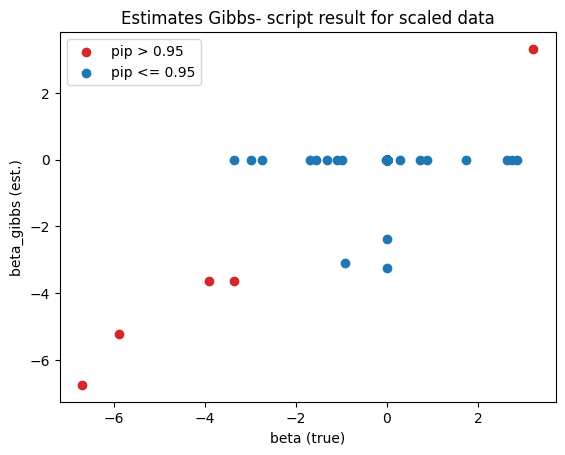

In [142]:
import pandas as pd

df = pd.read_csv("simulations/scenario_1/22/gibbs_22_beta.csv")
df["beta_est"] = df.beta_cond_mean * (df.pip >0.5).astype(int)

mask = df.pip > 0.95
beta_gibbs = df.beta_est

plt.scatter(beta[mask], beta_gibbs[mask], color="tab:red", label="pip > 0.95")
plt.scatter(beta[~mask], beta_gibbs[~mask], color="tab:blue", label="pip <= 0.95")
plt.title("Estimates Gibbs- script result for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_gibbs (est.)")
plt.legend()
plt.show()